In [2]:

%pip install requests
%pip install Pillow
%pip install matplotlib
%pip install numpy
%pip install --upgrade tensorflow

Note: you may need to restart the kernel to use updated packages.Requirement already satisfied: requests in d:\pytho3\lib\site-packages (2.32.5)




[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.Requirement already satisfied: matplotlib in d:\pytho3\lib\site-packages (3.9.2)




[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
%pip install tensorflow==2.15.0

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement tensorflow==2.15.0 (from versions: 2.16.0rc0, 2.16.1, 2.16.2, 2.17.0rc0, 2.17.0rc1, 2.17.0, 2.17.1, 2.18.0rc0, 2.18.0rc1, 2.18.0rc2, 2.18.0, 2.18.1, 2.19.0rc0, 2.19.0, 2.19.1, 2.20.0rc0, 2.20.0, 2.21.0rc0, 2.21.0rc1, 2.21.0)

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for tensorflow==2.15.0


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os
import shutil
from sklearn.model_selection import train_test_split

In [5]:
root_dir = 'E:/Mango_Leaf_Disease_Prediction/dataset/main dataset'

train_path= 'E:/Mango_Leaf_Disease_Prediction/dataset/train'
val_path= 'E:/Mango_Leaf_Disease_Prediction/dataset/val'

os.makedirs(train_path, exist_ok=True)
os.makedirs(val_path, exist_ok=True)


classes = ['Anthracnose', 'Bacterial Canker', 'Cutting Weevil', 'Die Back', 'Gall Midge', 'Healthy', 'Powdery Mildew', 'Sooty Mould']

validation_split = 0.2
for cls in classes:
    class_dir = os.path.join(root_dir, cls)
    train_class_dir = os.path.join(train_path, cls)
    val_class_dir = os.path.join(val_path, cls)

    # Check if class directory exists
    if not os.path.exists(class_dir):
        print(f"Warning: Directory not found: {class_dir}")
        continue

    # Create class directories in train and validation folders
    os.makedirs(train_class_dir, exist_ok=True)
    os.makedirs(val_class_dir, exist_ok=True)

    # List all images in the class directory
    images = os.listdir(class_dir)
    
    # Skip if no images found
    if len(images) == 0:
        print(f"Warning: No images found in {class_dir}")
        continue

    # Ensure minimum images for both train and val (at least 1 in each)
    min_train_size = max(1, int(len(images) * (1 - validation_split)))
    if min_train_size < 1:
        print(f"Warning: Not enough images for {cls} to split (only {len(images)} images). Using 80/20 split.")
        min_train_size = max(1, len(images) - 1)
    
    # Split images into train and validation sets with shuffle enabled
    train_images, val_images = train_test_split(images, test_size=validation_split, random_state=42, shuffle=True)
    
    # Ensure we have images in both sets
    if len(train_images) == 0 and len(val_images) > 0:
        print(f"Rebalancing {cls}: moving one image from val to train")
        train_images = val_images[:1]
        val_images = val_images[1:]
    
    print(f"{cls}: {len(train_images)} train images, {len(val_images)} val images")

    # Move images to train and validation folders
    for image in train_images:
        src = os.path.join(class_dir, image)
        dst = os.path.join(train_class_dir, image)
        shutil.move(src, dst)

    for image in val_images:
        src = os.path.join(class_dir, image)
        dst = os.path.join(val_class_dir, image)
        shutil.move(src, dst)

In [6]:
train_image_count = sum(len(files) for _, _, files in os.walk(train_path))
val_image_count = sum(len(files) for _, _, files in os.walk(val_path))

print(f"Total training images: {train_image_count}")
print(f"Total validation images: {val_image_count}")

Total training images: 3200
Total validation images: 800


In [7]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=(224, 224),
    batch_size=32,
    shuffle=True
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    val_path,
    image_size=(224, 224),
    batch_size=32,
    shuffle=False
)

# Get class names from the dataset
class_names = train_dataset.class_names
print(f"Class names: {class_names}")

Found 3200 files belonging to 8 classes.
Found 800 files belonging to 8 classes.
Class names: ['Anthracnose', 'Bacterial Canker', 'Cutting Weevil', 'Die Back', 'Gall Midge', 'Healthy', 'Powdery Mildew', 'Sooty Mould']


In [8]:
import pathlib
import PIL
train_data_dir = pathlib.Path(train_path)
val_data_dir = pathlib.Path(val_path)
Anthracnose_train = list(train_data_dir.glob('Anthracnose/*'))
Anthracnose_val = list(val_data_dir.glob('Anthracnose/*'))

print(len(Anthracnose_train))
print(len(Anthracnose_val))

400
100


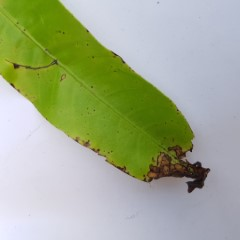

In [9]:
PIL.Image.open(str(Anthracnose_train[99]))


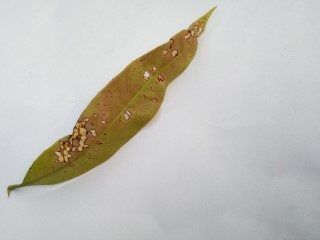

In [10]:
PIL.Image.open(str(Anthracnose_val[99]))

In [11]:
train_leaves_dict= {
    'Anthracnose': list(train_data_dir.glob('Anthracnose/*')),
        'Bacterial Canker': list(train_data_dir.glob('Bacterial Canker/*')),
        'Cutting Weevil': list(train_data_dir.glob('Cutting Weevil/*')),
        'Die Back': list(train_data_dir.glob('Die Back/*')),
        'Gall Midge': list(train_data_dir.glob('Gall Midge/*')),
        'Healthy': list(train_data_dir.glob('Healthy/*')),
        'Powdery Mildew': list(train_data_dir.glob('Powdery Mildew/*')),
        'Sooty Mould': list(train_data_dir.glob('Sooty Mould/*'))
}

val_leaves_dict= {
    'Anthracnose': list(val_data_dir.glob('Anthracnose/*')),
        'Bacterial Canker': list(val_data_dir.glob('Bacterial Canker/*')),
        'Cutting Weevil': list(val_data_dir.glob('Cutting Weevil/*')),
        'Die Back': list(val_data_dir.glob('Die Back/*')),
        'Gall Midge': list(val_data_dir.glob('Gall Midge/*')),
        'Healthy': list(val_data_dir.glob('Healthy/*')),
        'Powdery Mildew': list(val_data_dir.glob('Powdery Mildew/*')),
        'Sooty Mould': list(val_data_dir.glob('Sooty Mould/*'))

}

In [12]:
train_leaves_labels={
    'Anthracnose': 0,
        'Bacterial Canker': 1,
        'Cutting Weevil': 2,
        'Die Back': 3,
        'Gall Midge': 4,
        'Healthy': 5,
        'Powdery Mildew': 6,
        'Sooty Mould': 7
}

val_leaves_labels={
    'Anthracnose': 0,
        'Bacterial Canker': 1,
        'Cutting Weevil': 2,
        'Die Back': 3,
        'Gall Midge': 4,
        'Healthy': 5,
        'Powdery Mildew': 6,
        'Sooty Mould': 7
}

In [13]:
import cv2 

img=cv2.imread(str(train_leaves_dict['Anthracnose'][0]))
img.shape

(320, 240, 3)

In [14]:
X_train=[]
y_train=[]

for cls, images in train_leaves_dict.items(): 
    for image in images:
        img=cv2.imread(str(image))
        img=cv2.resize(img,(224,224))
        X_train.append(img)
        y_train.append(train_leaves_labels[cls])






In [15]:
X_train_scaled=np.array(X_train)/255

X_train_scaled

array([[[[0.89803922, 0.83921569, 0.80392157],
         [0.89803922, 0.83921569, 0.80392157],
         [0.89803922, 0.83921569, 0.80392157],
         ...,
         [0.8       , 0.71372549, 0.63921569],
         [0.8       , 0.71372549, 0.64313725],
         [0.8       , 0.71372549, 0.64313725]],

        [[0.89803922, 0.83921569, 0.80392157],
         [0.89803922, 0.83921569, 0.80392157],
         [0.89803922, 0.83921569, 0.80392157],
         ...,
         [0.79607843, 0.70980392, 0.63921569],
         [0.79607843, 0.70980392, 0.63921569],
         [0.79607843, 0.70980392, 0.63921569]],

        [[0.89803922, 0.83921569, 0.80392157],
         [0.89803922, 0.83921569, 0.80392157],
         [0.89803922, 0.83921569, 0.80392157],
         ...,
         [0.8       , 0.71372549, 0.64313725],
         [0.8       , 0.71372549, 0.64313725],
         [0.8       , 0.71372549, 0.64313725]],

        ...,

        [[0.81960784, 0.74117647, 0.6745098 ],
         [0.81960784, 0.74117647, 0.6745098 ]

In [16]:
X_val=[]
y_val=[]

for cls, images in val_leaves_dict.items():
    for image in images:
        img=cv2.imread(str(image))
        img=cv2.resize(img,(224,224))
        X_val.append(img)
        y_val.append(val_leaves_labels[cls])



        

In [17]:
X_val_scaled=np.array(X_val)/255    


Data Augmentation

In [18]:
train_datagen=ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)


val_datagen=ImageDataGenerator()

train_generator=train_datagen.flow(X_train_scaled, y_train, batch_size=32)
val_generator=val_datagen.flow(X_val_scaled, y_val, batch_size=32)


CNN


In [19]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras import layers

# Base model
base = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base.trainable = False

NUM_CLASSES = 8
# Custom head
x = layers.GlobalAveragePooling2D()(base.output)
x = layers.Dense(512, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)
predictions = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=base.input, outputs=predictions)

# Compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [20]:
history=model.fit(
    train_generator, 
    epochs=10, 
    validation_data=val_generator, 
    steps_per_epoch=len(train_generator),
     validation_steps=len(val_generator)
     )


Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 190s 2s/step - accuracy: 0.8741 - loss: 0.4087 - val_accuracy: 0.9500 - val_loss: 0.1553
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 143s 1s/step - accuracy: 0.9591 - loss: 0.1211 - val_accuracy: 0.9725 - val_loss: 0.0730
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 197s 2s/step - accuracy: 0.9628 - loss: 0.1100 - val_accuracy: 0.9787 - val_loss: 0.0599
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 177s 2s/step - accuracy: 0.9653 - loss: 0.0853 - val_accuracy: 0.9837 - val_loss: 0.0464
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 203s 2s/step - accuracy: 0.9725 - loss: 0.0774 - val_accuracy: 0.9850 - val_loss: 0.0449
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 178s 2s/step - accuracy: 0.9806 - loss: 0.0553 - val_accuracy: 0.9950 - val_loss: 0.0199
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 177s 2s/step - accuracy: 0.9756 - loss: 0.0631 - val_accuracy: 0.9875 - val_loss: 0.0334
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 172s 2s/step - accuracy: 0.9809 - loss: 0.0596 - val_accu

100/100 ━━━━━━━━━━━━━━━━━━━━ 114s 1s/step - accuracy: 0.9884 - loss: 0.0298
25/25 ━━━━━━━━━━━━━━━━━━━━ 21s 852ms/step - accuracy: 0.9875 - loss: 0.0345
Metrics for Training Set:
Loss: 0.02982460893690586
Accuracy: 0.9884374737739563

Metrics for Validation Set:
Loss: 0.03449631109833717
Accuracy: 0.987500011920929

Tabular Form of Metrics:
      Dataset      Loss  Accuracy
0    Training  0.029825  0.988437
1  Validation  0.034496  0.987500


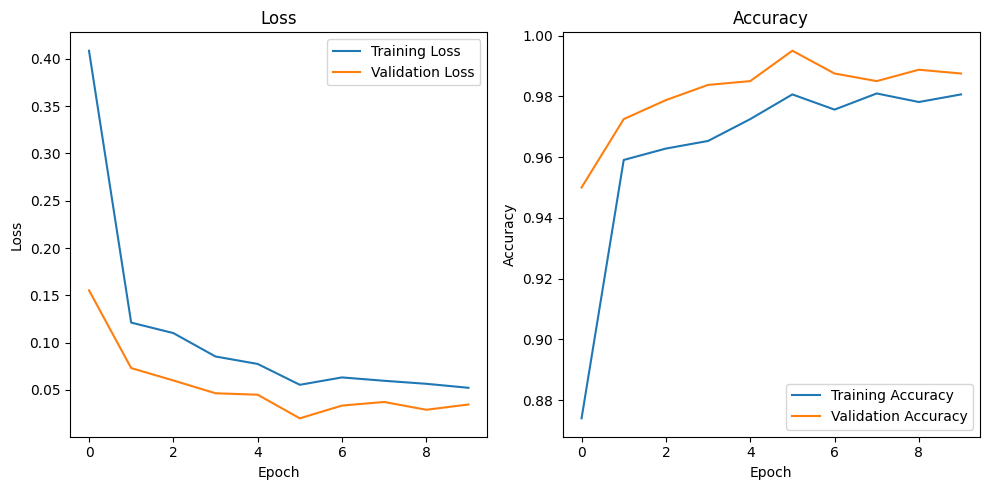

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# Evaluate the model on the training data
train_metrics = model.evaluate(train_generator)

# Evaluate the model on the validation data
val_metrics = model.evaluate(val_generator)

# Print the metrics for the training set
print("Metrics for Training Set:")
print(f"Loss: {train_metrics[0]}")
print(f"Accuracy: {train_metrics[1]}")

# Print the metrics for the validation set
print("\nMetrics for Validation Set:")
print(f"Loss: {val_metrics[0]}")
print(f"Accuracy: {val_metrics[1]}")

# Create a table of metrics
metrics_df = pd.DataFrame({
    'Dataset': ['Training', 'Validation'],
    'Loss': [train_metrics[0], val_metrics[0]],
    'Accuracy': [train_metrics[1], val_metrics[1]]
})

print("\nTabular Form of Metrics:")
print(metrics_df)

# Plotting the metrics
plt.figure(figsize=(10, 5))

# Plotting loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plotting accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

Prediction

In [22]:

model.save('mango_leaf_disease_MobileNetV2_model.h5')
model.save('E:\\Mango_Leaf_Disease_Prediction\\backend\\models\\mango_leaf_disease_MobileNetV2_model.h5')


In [27]:
model.save('mango_leaf_disease_model_MobileNetV2.keras')
model.save('E:\\Mango_Leaf_Disease_Prediction\\backend\\models\\mango_leaf_disease_model_MobileNetV2.keras')

In [23]:
load_model = tf.keras.models.load_model('mango_leaf_disease_MobileNetV2_model.h5')

In [30]:
load_model2= tf.keras.models.load_model('mango_leaf_disease_model_MobileNetV2.keras')

d:\pytho3\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 8 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [31]:
from tensorflow.keras.preprocessing import image
import numpy as np

# Define the path to the new image you want to test
new_image_path = "E:\\Mango_Leaf_Disease_Prediction\\IMG_20211106_143242 (Custom).jpg"
image_size = (224, 224)  # Same size as the training images
# Load and preprocess the new image
img = image.load_img(new_image_path, target_size=image_size)
img = image.img_to_array(img)
img = np.expand_dims(img, axis=0)
img = img / 255.0  # Normalize pixel values

In [32]:
predictions = load_model.predict(img)

# Get class labels and corresponding probabilities
class_labels = {v: k for k, v in train_leaves_labels.items()}
predicted_class = class_labels[np.argmax(predictions)]

# Print the result
print(f"The predicted class is: {predicted_class}")
print(f"Prediction probabilities: {predictions[0]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
The predicted class is: Bacterial Canker
Prediction probabilities: [4.57220715e-08 9.79734242e-01 8.54504151e-07 1.23792825e-08
 2.00875197e-02 3.69649570e-05 3.88571930e-09 1.40382981e-04]
